# 非線形

## 多項式特徴量

In [1]:
import seaborn as sns
df = sns.load_dataset('mpg')
df.dropna(inplace=True)

In [2]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


<Axes: xlabel='horsepower', ylabel='mpg'>

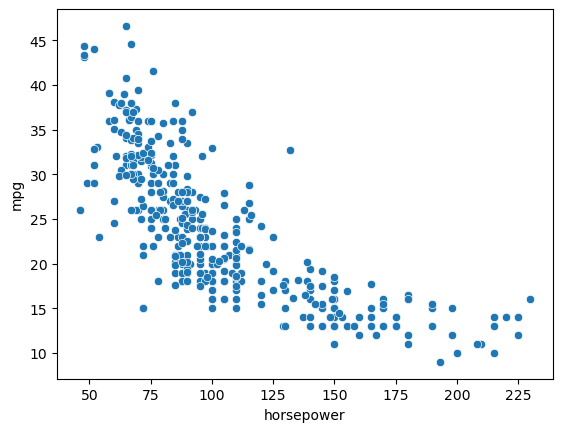

In [3]:
X = df['horsepower'].values.reshape(-1, 1)
y = df['mpg']
sns.scatterplot(x=df['horsepower'], y=df['mpg'])

In [11]:
# 多項式特徴量
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(2, include_bias=False)

In [12]:
poly

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [6]:
# poly.fit(X)
# poly.transform(X)
X_poly = poly.fit_transform(X)

In [7]:
# 線形回帰
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


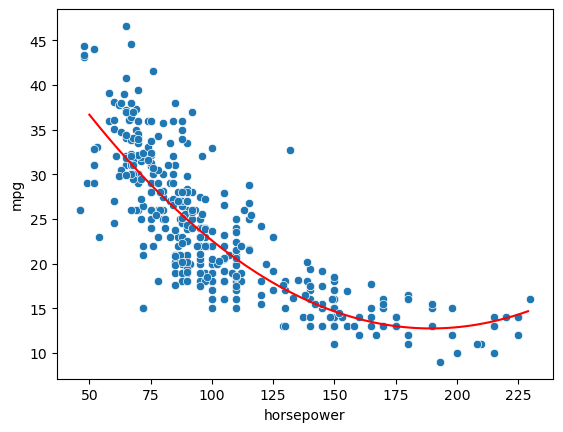

In [10]:
# 描画
import numpy as np
import matplotlib.pyplot as plt
x_axis = np.arange(50, 230).reshape(-1, 1)
x_axis_ = poly.fit_transform(x_axis)
pred = model.predict(x_axis_)
sns.scatterplot(x=df['horsepower'], y=df['mpg'])
plt.plot(x_axis, pred, 'r')

# 線形回帰　VS 非線形

In [25]:
from sklearn.model_selection import cross_val_score, RepeatedKFold
from sklearn.pipeline import Pipeline

In [21]:
X = df['horsepower'].values.reshape(-1, 1)
y = df['mpg']
degrees = [1, 2, 3]
model = LinearRegression()
k = 5
n_repeats = 3
cv = RepeatedKFold(n_splits=k, n_repeats=n_repeats, random_state=0)
results = {}
for d in degrees:
    poly = PolynomialFeatures(d)
    X_poly = poly.fit_transform(X)
    scores = cross_val_score(model, X_poly, y, scoring='neg_mean_squared_error', cv=cv)
    results[f"degree{d}"] = {'scores_mean':-np.mean(scores), 'scores_std':np.std(scores)}

In [18]:
scores

array([-15.91065108, -22.1624462 , -21.16531541, -24.32069337,
       -12.95586189, -18.54514929, -17.03665635, -31.06863501,
       -14.68685054, -16.08622087, -17.7286585 , -20.30767593,
       -17.0969599 , -17.68090829, -24.75449275])

In [22]:
results

{'degree1': {'scores_mean': np.float64(24.235391801372007),
  'scores_std': np.float64(3.3466777741729725)},
 'degree2': {'scores_mean': np.float64(19.294969517171623),
  'scores_std': np.float64(4.413627004206255)},
 'degree3': {'scores_mean': np.float64(19.43381169297633),
  'scores_std': np.float64(4.5082238230144975)}}

In [24]:
import pandas as pd
pd.DataFrame(results)

,degree1,degree2,degree3
scores_mean,24.235392,19.294970,19.433812
scores_std,3.346678,4.413627,4.508224


In [26]:
X = df['horsepower'].values.reshape(-1, 1)
y = df['mpg']
degrees = [1, 2, 3]
k = 5
n_repeats = 3
cv = RepeatedKFold(n_splits=k, n_repeats=n_repeats, random_state=0)
results = {}
for d in degrees:
    pipeline = Pipeline(steps=[('poly', PolynomialFeatures(d)), ('model', LinearRegression())])
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=cv)
    results[f"degree{d}"] = {'scores_mean':-np.mean(scores), 'scores_std':np.std(scores)}

In [27]:
pd.DataFrame(results)

,degree1,degree2,degree3
scores_mean,24.235392,24.235392,24.235392
scores_std,3.346678,3.346678,3.346678
